In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

# Load data

In [2]:
RESULTS_DIR = Path('/nlp/scr/salilg/showcase_property_tax/results/per_county_scaling')

df = pd.read_csv(RESULTS_DIR / 'test_v4' / 'results.csv')
df = df[df['status'] == 'success'].copy()

print(f'Rows: {len(df)}')
print(f'Models: {df["model"].unique()}')
print(f'Size buckets: {df["size_bucket"].unique()}')
print(f'Train sizes: {sorted(df["requested_train_size"].unique())}')
print(f'Counties per bucket:')
print(df.groupby('size_bucket')['fips'].nunique())
df.head()

Rows: 922
Models: ['tabpfn' 'xgboost']
Size buckets: ['small' 'tiny']
Train sizes: [np.int64(5), np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60)]
Counties per bucket:
size_bucket
small    49
tiny     58
Name: fips, dtype: int64


,fips,size_bucket,county_train_pool_size,county_test_size,requested_train_size,actual_train_size,seed,model,n_features,fit_time,pred_time,r2,mae,rmse,mape,mse,status,experiment_name,experiment_description
0,1011,small,68,18,5,5,42,tabpfn,107,7.318617,1.229466,-0.695801,47420.592278,56585.259001,79.722782,3.201892e+09,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
1,1011,small,68,18,5,5,42,xgboost,107,24.303303,0.015225,-1.008521,52343.903693,61582.035942,95.650416,3.792347e+09,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
2,1011,small,68,18,10,10,42,tabpfn,107,1.018223,0.308450,-1.139118,171737.505680,247560.477952,190.965807,6.128619e+10,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
3,1011,small,68,18,10,10,42,xgboost,107,24.585517,0.014611,0.055393,89942.847206,164508.995803,64.902441,2.706321e+10,success,per_county_scaling_test_v4,Per-county learning curves for test_v4
4,1011,small,68,18,20,20,42,tabpfn,107,1.006737,0.302279,0.939738,32073.974573,41550.427624,44.777383,1.726438e+09,success,per_county_scaling_test_v4,Per-county learning curves for test_v4


# Helper functions

In [3]:
def format_model_name(model_name):
    if model_name == 'tabpfn':
        return 'TabPFN'
    elif model_name == 'xgboost':
        return 'XGBoost'
    else:
        return model_name


BUCKET_ORDER = ['tiny', 'small', 'medium']
MODEL_LINESTYLE = {'tabpfn': '-', 'xgboost': '--'}
MODEL_MARKER   = {'tabpfn': 'o', 'xgboost': 'x'}

In [4]:
def plot_learning_curves(
    df,
    metric='mape',
    train_size_col='requested_train_size',
    buckets=None,
    ylim=None,
    n_se=2,
    show_n=True,
):
    """
    Plot mean ± n_se*SE of `metric` vs train size, faceted by size bucket.
    Colors = size bucket, line styles = model.
    """
    if buckets is None:
        buckets = [b for b in BUCKET_ORDER if b in df['size_bucket'].unique()]

    # Aggregate
    stats = (
        df
        .groupby([train_size_col, 'model', 'size_bucket'])[metric]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    stats['se'] = stats['std'] / np.sqrt(stats['count'])

    palette = sns.color_palette('tab10', n_colors=len(buckets))
    bucket_color = {b: palette[i] for i, b in enumerate(buckets)}

    n_buckets = len(buckets)
    fig, axes = plt.subplots(1, n_buckets, figsize=(6 * n_buckets, 5), sharey=True)
    if n_buckets == 1:
        axes = [axes]

    for ax, bucket in zip(axes, buckets):
        sub = stats[stats['size_bucket'] == bucket]

        models = sorted(sub['model'].unique())
        offsets = {m: (i - len(models) / 2) * 0.4 for i, m in enumerate(models)}

        for model, mdf in sub.groupby('model'):
            mdf = mdf.sort_values(train_size_col)
            x = mdf[train_size_col] + offsets[model]
            ax.errorbar(
                x, mdf['mean'],
                yerr=n_se * mdf['se'],
                fmt=MODEL_MARKER.get(model, 'o'),
                linestyle=MODEL_LINESTYLE.get(model, '-'),
                color=bucket_color[bucket],
                capsize=3, linewidth=2, markersize=5,
                label=format_model_name(model),
            )

        xs = sorted(sub[train_size_col].unique())
        ax.set_xticks(xs)
        if show_n:
            # n = county count at each train size (use tabpfn as reference)
            n_per_size = sub[sub['model'] == sub['model'].iloc[0]].set_index(train_size_col)['count']
            ax.set_xticklabels([f'{x}\n(n={n_per_size.get(x, "")} counties)' for x in xs], fontsize=8)
        ax.set_xlabel('Train size')
        ax.set_ylabel(metric.upper() if ax == axes[0] else '')
        ax.set_title(f'{bucket.capitalize()} counties')
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        if ylim:
            ax.set_ylim(ylim)
        ax.legend(title='Model', handlelength=3)

    fig.suptitle(
        f'{metric.upper()} vs train size  |  mean ± {n_se} SE  |  test_v4',
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.show()

# Learning curves

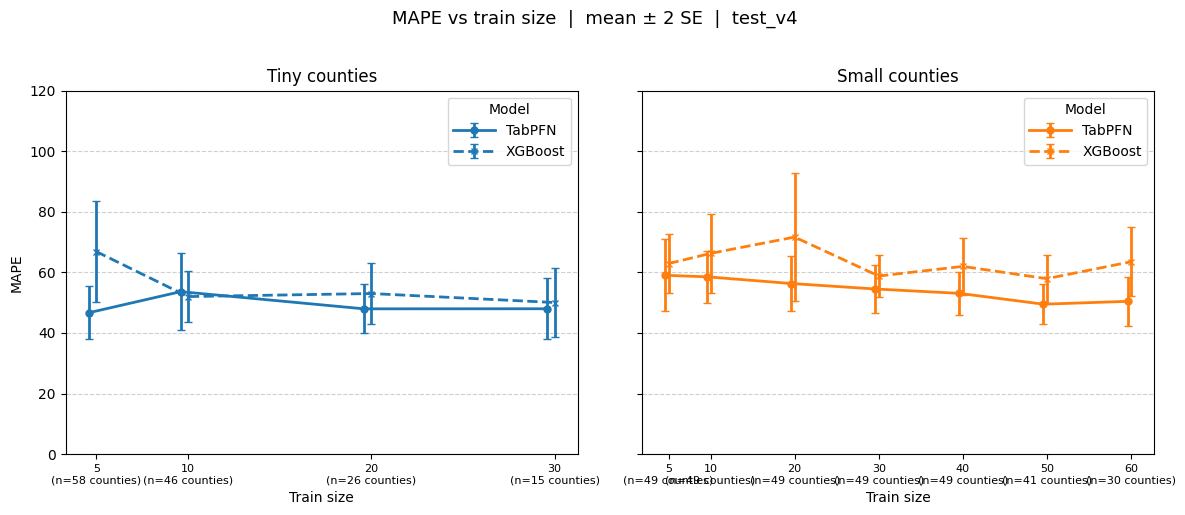

In [5]:
plot_learning_curves(df, metric='mape', ylim=(0, 120))

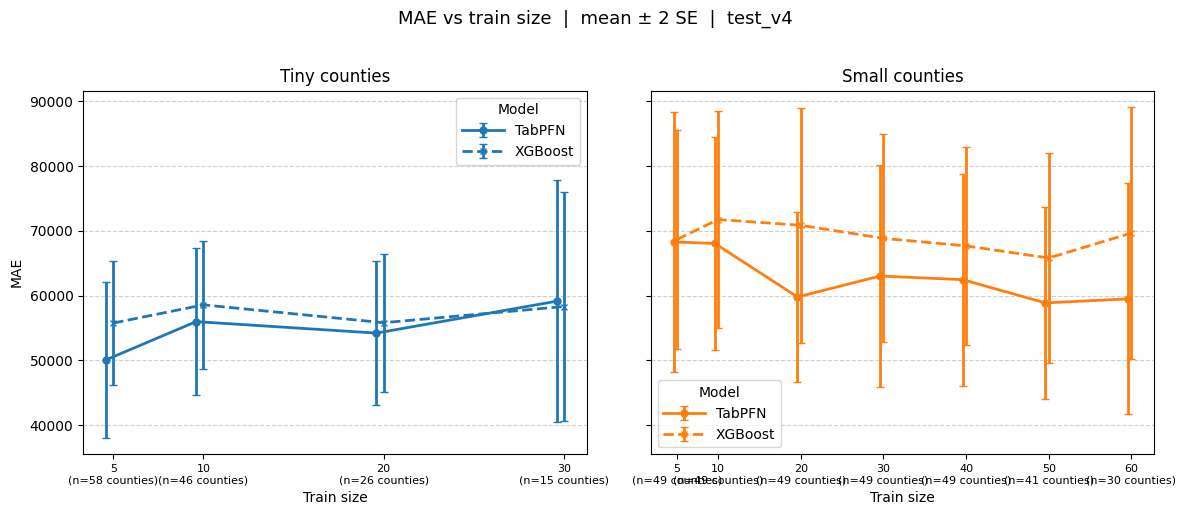

In [7]:
plot_learning_curves(df, metric='mae')

# Combined view: tiny + small on same axes

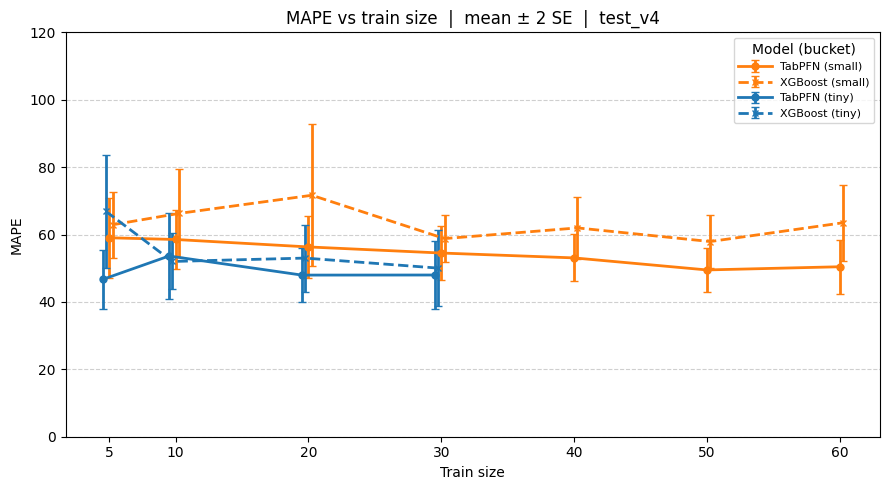

In [8]:
def plot_learning_curves_combined(
    df,
    metric='mape',
    train_size_col='requested_train_size',
    ylim=None,
    n_se=2,
):
    """
    Single axes plot. Colors = size bucket, line styles = model.
    """
    buckets = [b for b in BUCKET_ORDER if b in df['size_bucket'].unique()]

    stats = (
        df
        .groupby([train_size_col, 'model', 'size_bucket'])[metric]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    stats['se'] = stats['std'] / np.sqrt(stats['count'])

    palette = sns.color_palette('tab10', n_colors=len(buckets))
    bucket_color = {b: palette[i] for i, b in enumerate(buckets)}

    fig, ax = plt.subplots(figsize=(9, 5))

    combos = [(b, m) for b in buckets for m in sorted(stats['model'].unique())]
    offsets = {c: (i - len(combos) / 2) * 0.25 for i, c in enumerate(combos)}

    for (bucket, model), mdf in stats.groupby(['size_bucket', 'model']):
        mdf = mdf.sort_values(train_size_col)
        x = mdf[train_size_col] + offsets[(bucket, model)]
        ax.errorbar(
            x, mdf['mean'],
            yerr=n_se * mdf['se'],
            fmt=MODEL_MARKER.get(model, 'o'),
            linestyle=MODEL_LINESTYLE.get(model, '-'),
            color=bucket_color[bucket],
            capsize=3, linewidth=2, markersize=5,
            label=f'{format_model_name(model)} ({bucket})',
        )

    ax.set_xticks(sorted(stats[train_size_col].unique()))
    ax.set_xlabel('Train size')
    ax.set_ylabel(metric.upper())
    if ylim:
        ax.set_ylim(ylim)
    ax.set_title(f'{metric.upper()} vs train size  |  mean ± {n_se} SE  |  test_v4')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(title='Model (bucket)', handlelength=3, fontsize=8)
    plt.tight_layout()
    plt.show()


plot_learning_curves_combined(df, metric='mape', ylim=(0, 120))

# County-level distributions at each train size

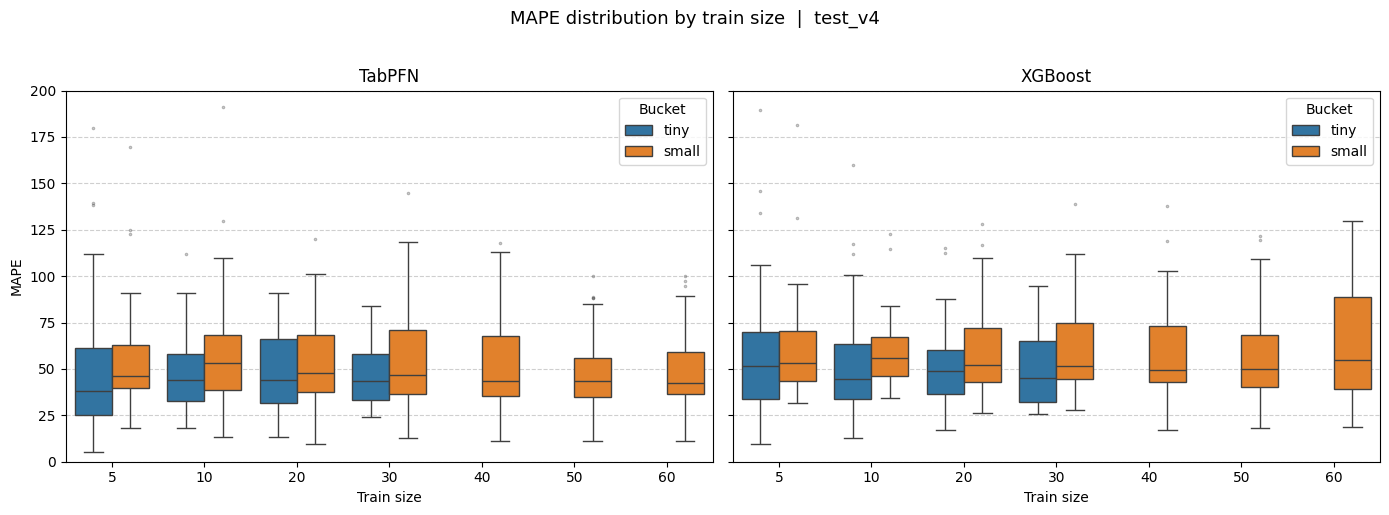

In [10]:
def plot_distributions(
    df,
    metric='mape',
    train_size_col='requested_train_size',
    ylim=None,
):
    """
    Box plots: one panel per model, x = train size, hue = size bucket.
    """
    buckets = [b for b in BUCKET_ORDER if b in df['size_bucket'].unique()]
    df = df.copy()
    df['size_bucket'] = pd.Categorical(df['size_bucket'], categories=buckets, ordered=True)

    models = sorted(df['model'].unique())
    fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 5), sharey=True)
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        sub = df[df['model'] == model]
        sns.boxplot(
            data=sub,
            x=train_size_col,
            y=metric,
            hue='size_bucket',
            ax=ax,
            flierprops=dict(marker='.', markersize=3, alpha=0.4),
        )
        ax.set_title(format_model_name(model))
        ax.set_xlabel('Train size')
        ax.set_ylabel(metric.upper() if ax == axes[0] else '')
        if ylim:
            ax.set_ylim(ylim)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        ax.legend(title='Bucket')

    fig.suptitle(f'{metric.upper()} distribution by train size  |  test_v4', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


plot_distributions(df, metric='mape', ylim=(0, 200))